In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [2]:
class AgentState(TypedDict):
    message : str 

In [3]:
# Defining a node

def greeter_node(state : AgentState) -> AgentState:
    """ Simple node that adds a greeting message to the state """
    msg = "Hello there " + state['message'] + "!"
    state['message'] = msg 
    return state

In [4]:
graph = StateGraph(AgentState)

# Single node in our graph
graph.add_node("greeter node", greeter_node)

# No need to add START and END nodes in the graph as they are in it by default
graph.add_edge(START, "greeter node")
graph.add_edge("greeter node", END)

# graph.set_entry_point("greeter node")
# graph.set_finish_point("greeter node")

app = graph.compile()

In [5]:
result = app.invoke({"message" : "Aditya"})
result['message']

'Hello there Aditya!'

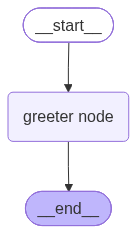

In [6]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))
